In [26]:
import math
from pathlib import Path
import cvxpy as cp
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.dataset import get_portfolio_returns_df
from mis_dro.experiments import ExperimentName
from mis_dro.constants import IN_SAMPLE_TIME_WINDOW, OUT_OF_SAMPLE_TIME_WINDOW
from mis_dro.plot import *

In [27]:
mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
dgp = "DowJones"
returns_df = get_portfolio_returns_df(mmc2_dir, "DowJones-crash")
index_returns_df = pd.read_excel(mmc2_dir / "Datasets" / "DowJones" / f"DowJones.xlsx", sheet_name="Index_Returns", header=None)

In [28]:
experiment_name = ExperimentName.kl_portfolio_crash
experiment_dir = Path("/dcs/large/u1508153/misdro/kl_portfolio_crash")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])
all_results_df["algorithm"].unique()

array(['kl_dro_bas', 'kl_bdro', 'kl_pp'], dtype=object)

In [29]:
results_df = preprocess_results_df(all_results_df, "DowJones-crash", dataset="portfolio")
agg_df = get_agg_df(results_df, gb_cols=["algorithm", "epsilon"])
agg_df

/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:199: FutureWarning: The provided callable <function mean at 0x7fd4080c6480> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg20/u1508153/projects/mis-dro-code/mis_dro/plot.py:199: FutureWarning: The provided callable <function std at 0x7fd4080c65c0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  out_of_sample_var  \
algorithm  epsilon                                          
kl_bdro    0.00001        6.569550e-03       3.420800e-03   
           0.00002        6.569518e-03       3.420769e-03   
           0.00005        6.569641e-03       3.420854e-03   
           0.00010        6.569693e-03       3.420900e-03   
           0.00020        5.736961e-03       3.121825e-03   
           0.00050        3.248053e-03       1.713550e-03   
           0.00100        2.334425e-03       1.370607e-03   
           0.00200        1.775663e-03       1.290925e-03   
           0.00500        1.397023e-03       1.252404e-03   
           0.01000        1.256886e-03       1.234157e-03   
           0.02000        1.159654e-03       1.212860e-03   
           0.05000        1.083693e-03       1.198850e-03   
           0.10000        1.045729e-03       1.192549e-03   
           0.20000        1.019588e-03       1.188576e-03   
           0.50000        9.961252e-04       1.185209e-03   
           1.00000        9.848033e-04       1.183531e-03   
kl_dro_bas 0.00001        6.569729e-03       3.420919e-03   
           0.00002        6.569728e-03       3.420918e-03   
           0.00005        6.569728e-03       3.420918e-03   
           0.00010        6.569729e-03       3.420919e-03   
           0.00020        6.569727e-03       3.420917e-03   
           0.00050        4.153247e-03       2.179486e-03   
           0.00100        2.904419e-03       1.583208e-03   
           0.00200        2.098322e-03       1.306207e-03   
           0.00500        1.528522e-03       1.257346e-03   
           0.01000        1.331692e-03       1.242215e-03   
           0.02000        1.207674e-03       1.219280e-03   
           0.05000        1.107747e-03       1.199967e-03   
           0.10000        1.061115e-03       1.192209e-03   
           0.20000        1.029050e-03       1.187343e-03   
           0.50000        1.001028e-03       1.183399e-03   
           1.00000        9.870059e-04       1.181530e-03   
kl_pp      0.00500        7.975385e-09       3.647361e-13   
           0.01000        1.382521e-10       1.039991e-16   
           0.02000        4.914244e-12       1.212819e-19   
           0.05000        2.257426e-09       2.415458e-14   
           0.10000        3.173762e-11       4.278987e-18   
           0.20000        3.602012e-14       5.701323e-24   
           0.50000        6.480726e-15       1.099895e-25   
           1.00000        3.172037e-12       2.790567e-20   

                    sum_of_in_group_var  var_of_in_group_mean  \
algorithm  epsilon                                              
kl_bdro    0.00001         3.420800e-03                   NaN   
           0.00002         3.420769e-03                   NaN   
           0.00005         3.420854e-03                   NaN   
           0.00010         3.420900e-03                   NaN   
           0.00020         3.121825e-03                   NaN   
           0.00050         1.713550e-03                   NaN   
           0.00100         1.370607e-03                   NaN   
           0.00200         1.290925e-03                   NaN   
           0.00500         1.252404e-03                   NaN   
           0.01000         1.234157e-03                   NaN   
           0.02000         1.212860e-03                   NaN   
           0.05000         1.198850e-03                   NaN   
           0.10000         1.192549e-03                   NaN   
           0.20000         1.188576e-03                   NaN   
           0.50000         1.185209e-03                   NaN   
           1.00000         1.183531e-03                   NaN   
kl_dro_bas 0.00001         3.420919e-03                   NaN   
           0.00002         3.420918e-03                   NaN   
           0.00005         3.420918e-03                   NaN   
           0.00010         3.420919e-03                   NaN   
           0.00020         

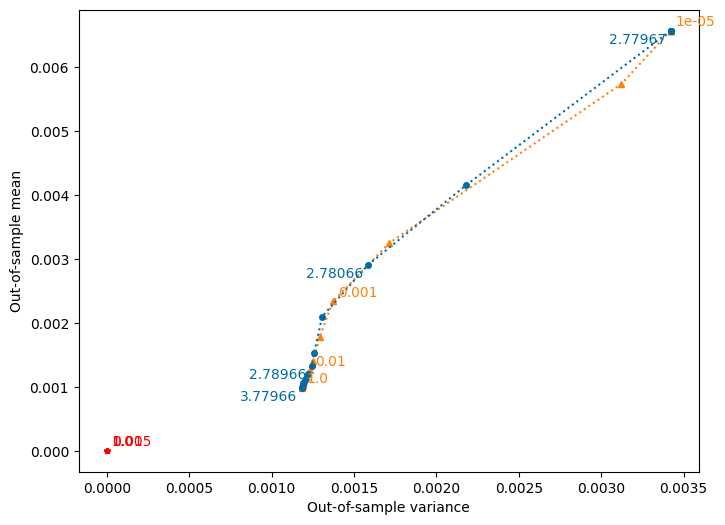

In [30]:
log_partition_constant = results_df.loc[results_df["algorithm"] == "kl_dro_bas"]["log_partition_constant"].unique()[0]
fig, ax = plt.subplots(figsize=(8,6))
df = agg_df
df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
for algorithm, group_df in df.groupby("algorithm"):
    if algorithm == "kl_dro_bas":
        local_log_partition_constant = log_partition_constant
    else:
        local_log_partition_constant = 0
    mean_variance_plot(ax, group_df, is_labelled=True, offset=0.00003, alpha=1.0, **algorithm_inference_style(algorithm, "bayes"), special_epsilons=[0.00001, 0.001, 0.01, 1.0], add_log_partition_function=local_log_partition_constant)
ax.set_xlabel("Out-of-sample variance")
ax.set_ylabel("Out-of-sample mean")
fig.show()

In [38]:
num_replications = results_df["num_replications"].unique()[0]
out_of_sample_time_window = IN_SAMPLE_TIME_WINDOW * 4
num_time_windows = 1
num_stocks = int(len(returns_df.columns))
bdro_labelled = False
dro_bas_labelled = False
training_time_window_id = 72
oos_week_numbers = [training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW + IN_SAMPLE_TIME_WINDOW + i for i in range(out_of_sample_time_window)]
last_week = oos_week_numbers[len(oos_week_numbers)-1]

start_training_week = training_time_window_id * OUT_OF_SAMPLE_TIME_WINDOW # inclusive
end_training_week = start_training_week + IN_SAMPLE_TIME_WINDOW # not inclusive
test_start = end_training_week
test_end = test_start + out_of_sample_time_window

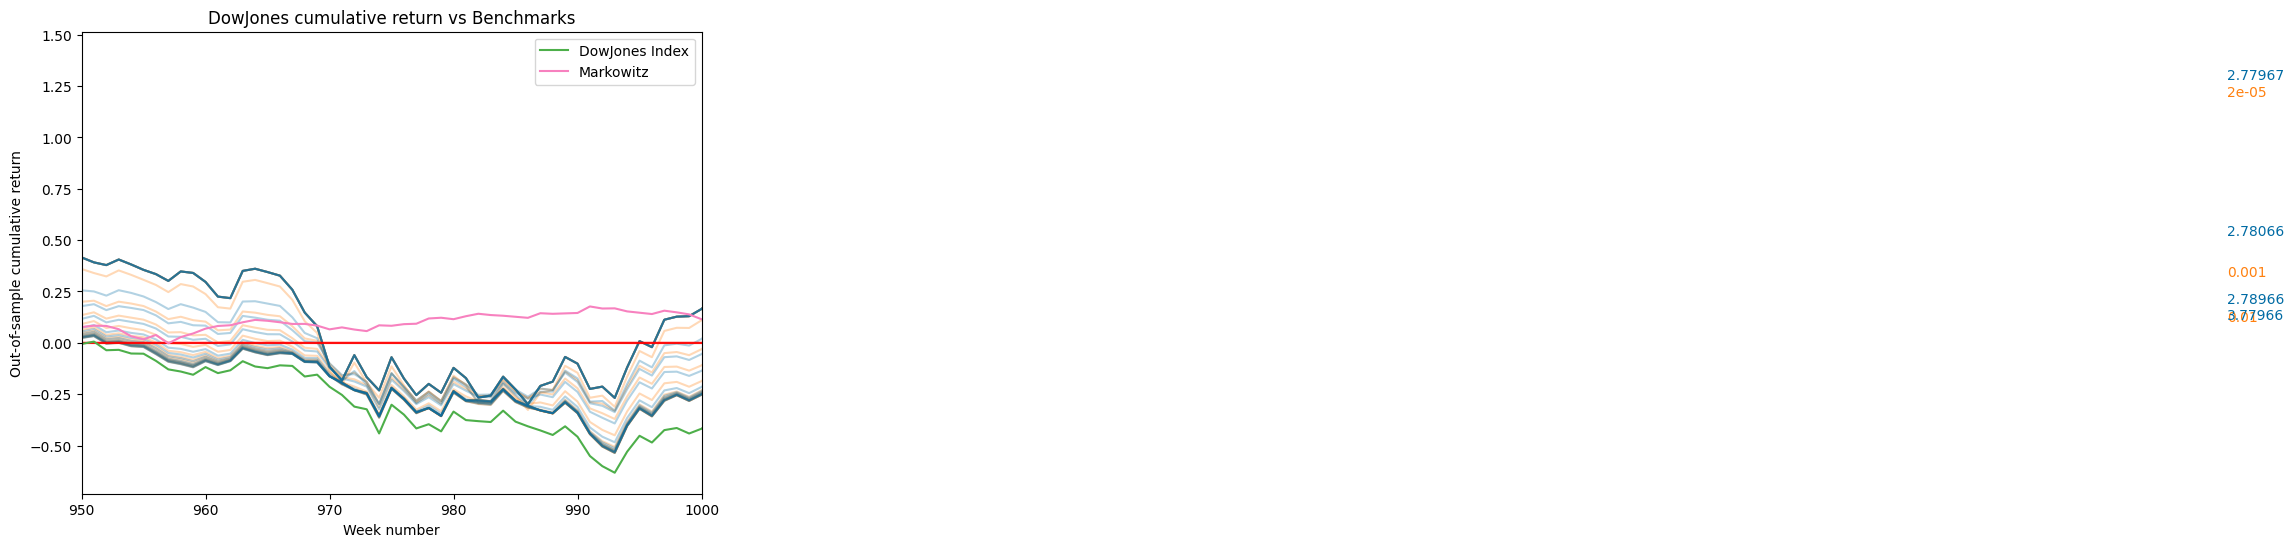

In [45]:
fig, ax = plt.subplots(figsize=(8,6))

for (algorithm, epsilon), group_df in results_df.groupby(["algorithm", "epsilon"]):
    # dro_returns = group_df[week_cols].values.flatten()
    # assert OUT_OF_SAMPLE_TIME_WINDOW * num_time_windows == len(group_df) * len(group_df["out_of_sample_cost"].values[0])
    cost_list = []
    for i in range(num_replications):
        cost_list += group_df["out_of_sample_cost"].values[i]
    dro_returns = np.array(cost_list)
    if not dro_bas_labelled and algorithm == "kl_dro_bas":
        label = AlgorithmName[algorithm].value
        dro_bas_labelled = True
    elif not bdro_labelled and algorithm == "kl_bdro":
        label = AlgorithmName[algorithm].value
        bdro_labelled = True
    else:
        label='_nolegend_'
    ax.plot(oos_week_numbers, np.cumsum(dro_returns), label=label, alpha=0.3, color=AlgorithmColor[algorithm].value)
    if algorithm == "kl_dro_bas" and epsilon in [0.00001, 0.001, 0.01, 1.0]:
        ax.text(last_week, np.cumsum(dro_returns)[test_end-4-end_training_week]-0.1, np.round(log_partition_constant + epsilon, 5), color=AlgorithmColor[algorithm].value)
    elif algorithm == "kl_bdro" and  epsilon in [0.00002, 0.001, 0.01]:
        ax.text(last_week, np.cumsum(dro_returns)[last_week-4-end_training_week]-0.1, epsilon, color=AlgorithmColor[algorithm].value)

CB_color_cycle = ['#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
ax.plot(oos_week_numbers, np.cumsum(index_returns_df.iloc[test_start:test_end].values), label=f"{dgp} Index", color=CB_color_cycle[0])
# for baseline_model in ["CZeSD", "KP_SSD", "L_SSD", "LR_ASSD", "MeanVar", "RMZ_SSD"]:

for i, baseline_model in enumerate(["MeanVar"]):
    baseline_model_label = baseline_model if baseline_model != "MeanVar" else "Markowitz"
    baseline_portfolio_txt = mmc2_dir / "Solutions" / dgp / f"OptPortfolios_{baseline_model}_{dgp}.txt"
    baseline_portfolio = np.loadtxt(baseline_portfolio_txt).T[:num_time_windows, :]
    baseline_returns_txt = mmc2_dir / "Solutions" / dgp / f"OutofSamplePortReturns_{baseline_model}_{dgp}_List.txt" 
    baseline_returns = np.loadtxt(baseline_returns_txt)
    ax.plot(oos_week_numbers, np.cumsum(baseline_returns[:out_of_sample_time_window * num_time_windows]), label=baseline_model_label, color=CB_color_cycle[i+1])

ax.set_xlabel("Week number")
ax.set_ylabel("Out-of-sample cumulative return")
# ax.set_xlim(2000)
ax.set_xlim(950, 1000)
# ax.set_ylim(-0.1, 9.5)
# ax.vlines(52, -0.3, 6.9, color="black", linestyle=":")
ax.set_title(dgp + r" cumulative return vs Benchmarks")
handles, labels = ax.get_legend_handles_labels()
order = [1,0,2,3]
# ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
ax.legend()
# plt.savefig(f"/Users/patrick/Experiments/misdro/paper_bas_figures/{experiment_name}_cum_returns_{filter_dgp}.pdf", bbox_inches="tight")

fig.show()